# bayesflow_hpo Quickstart

A minimal end-to-end example that shows how to run **hyperparameter optimization** (HPO) for a [BayesFlow 2.x](https://bayesflow.org) amortized inference workflow.

We will:

1. Define a simple Gaussian **simulator** (prior + likelihood).
2. Build a BayesFlow **adapter** that maps raw simulation output to the format expected by the neural network.
3. Generate a fixed **validation dataset** for simulation-based calibration (SBC) diagnostics.
4. Launch an Optuna-backed **multi-objective optimization** run that searches over network architectures and training hyperparameters.

## 0. Setup

Install the package (editable mode from the repo root) and import the two libraries we need:
- **`bayesflow`** — the core amortized Bayesian inference framework (simulators, adapters, workflows),
- **`bayesflow_hpo`** — this package, which adds HPO search spaces, objectives, and validation utilities on top.

In [1]:
%pip install --quiet --upgrade -e ..

import bayesflow as bf
import bayesflow_hpo as hpo
import numpy as np


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Matze\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


INFO:bayesflow:Using backend 'torch'


When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


C:\Users\Matze\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Simulator, Adapter & Validation Data

**Simulator** — We define a toy generative model with a 1-D Gaussian prior $\theta \sim \mathcal{N}(0, 1)$ and a Gaussian likelihood $x_i \mid \theta \sim \mathcal{N}(\theta, 1)$ producing 12 observations per dataset. This is deliberately simple so the notebook runs in seconds.

**Adapter** — The `bf.Adapter` tells BayesFlow how to reshape the raw simulation dictionaries into the tensor format the neural network expects:
- `.as_set(["x"])` marks observation vectors as exchangeable (order doesn't matter),
- `.rename("theta", "inference_variables")` maps the parameter to the inference target,
- `.concatenate(["x"], into="summary_variables")` stacks observations into the summary input.

**Validation data** — `hpo.generate_validation_dataset` draws a fixed batch of (parameter, data) pairs from the simulator. This dataset is reused across *every* HPO trial so that metric comparisons are fair (no noise from resampling).

In [ ]:
def prior_fn():
    return {"theta": np.random.normal(0.0, 1.0, size=(1,)).astype("float32")}


def likelihood_fn(theta):
    theta_value = float(np.squeeze(theta))
    x = np.random.normal(theta_value, 1.0, size=(12, 1)).astype("float32")
    return {"x": x}


simulator = bf.simulators.make_simulator([prior_fn, likelihood_fn])
adapter = (
    bf.Adapter()
    .as_set(["x"])
    .rename("theta", "inference_variables")
    .concatenate(["x"], into="summary_variables", axis=-1)
)

validation_data = hpo.generate_validation_dataset(
    simulator=simulator,
    param_keys=["theta"],
    data_keys=["x"],
    sims_per_condition=100,
)

## 2. Run HPO

`hpo.optimize` is the main entry point. Under the hood it:

1. **Creates an Optuna study** with two objectives: *calibration error* (minimize) and *model size* (minimize) — a Pareto-style trade-off between accuracy and complexity.
2. **Samples hyperparameters** from a `CompositeSearchSpace` that covers the inference network (coupling flow architecture), the summary network (DeepSet), and training settings (learning rate, batch size, etc.).
3. **Builds, trains, and validates** a fresh `bf.BasicWorkflow` for each trial, using SBC-based metrics on the fixed validation dataset.
4. **Reports results** back to Optuna, which guides future sampling via its TPE (Tree-structured Parzen Estimator) sampler.

Key arguments in this example:
| Argument | Value | Why |
|---|---|---|
| `n_trials` | 50 | Number of HPO configurations to try |
| `epochs=0` | auto | Let the search space decide epoch count (early stopping) |
| `batches_per_epoch` | 50 | Short training batches — keeps the demo fast |
| `show_progress_bar` | `False` | Avoids noisy output in notebooks |

After optimization, `study.best_trials` returns the Pareto-optimal trial(s).

In [ ]:
study = hpo.optimize(
    simulator=simulator,
    adapter=adapter,
    param_keys=["theta"],
    data_keys=["x"],
    validation_data=validation_data,
    n_trials=10,
    epochs=10,
    batches_per_epoch=20,
    max_param_count=100_000, # Set a low value to speed up the optimization for demonstration purposes.
    show_progress_bar=False,
)

print(f"Trials: {len(study.trials)}")
print(f"Best values: {study.best_trials[0].values}")

C:\Users\Matze\AppData\Local\Programs\Python\Python311\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
C:\Users\Matze\AppData\Local\Programs\Python\Python311\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``constraints_func`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-03-06 02:57:25,644] A new study created in memory with name: bayesflow_hpo


[I 2026-03-06 02:57:25,647] Trial 0 finished with values: [1.0, 1.5] and parameters: {'cf_depth': 6, 'cf_subnet_width': 256, 'cf_subnet_depth': 3, 'cf_dropout': 0.17959754525911098, 'cf_activation': 'silu', 'ds_summary_dim': 29, 'ds_depth': 3, 'ds_width': 192, 'ds_dropout': 0.006175348288740734, 'initial_lr': 0.0044447541666908135}.


INFO:bayesflow:Fitting on dataset instance of OnlineDataset.


INFO:bayesflow:Building on a test batch.


Epoch 1/10


...


Sampling: 100%|██████████| 1/1 [00:00<00:00,  4.11batch/s]


Sampling: 100%|██████████| 1/1 [00:00<00:00,  4.09batch/s]

[I 2026-03-06 03:06:44,536] Trial 25 finished with values: [0.14600000000000002, 0.7818365953331258] and parameters: {'cf_depth': 9, 'cf_subnet_width': 32, 'cf_subnet_depth': 1, 'cf_dropout': 0.024577600703423283, 'cf_activation': 'silu', 'ds_summary_dim': 12, 'ds_depth': 3, 'ds_width': 32, 'ds_dropout': 0.2613817627741418, 'initial_lr': 0.0010939279133569037}.


INFO:bayesflow_hpo.optimization.study:Completed 10 trained trials (26 total, 16 budget-rejected).


Trials: 26
Best values: [0.010000000000000009, 0.7812072498967901]


## 3. Inspect Results

### 3.1 Pareto Front

The optimization minimizes *two* objectives simultaneously:
- **Objective 0** — calibration error (lower = better-calibrated posterior approximation),
- **Objective 1** — normalized parameter count (lower = smaller model).

These objectives trade off against each other: a very large network may achieve low calibration error but is expensive to run. The **Pareto front** shows the set of trials that are not dominated — no other trial is simultaneously smaller *and* better calibrated.

### 3.2 Hyperparameter Importance

After all trials have run, Optuna's **fANOVA-based importance estimator** assigns each hyperparameter a score reflecting how much its variation explains the variance in objective 0 (calibration error). High-importance hyperparameters are worth tuning carefully in follow-up studies.

NameError: name 'hpo' is not defined

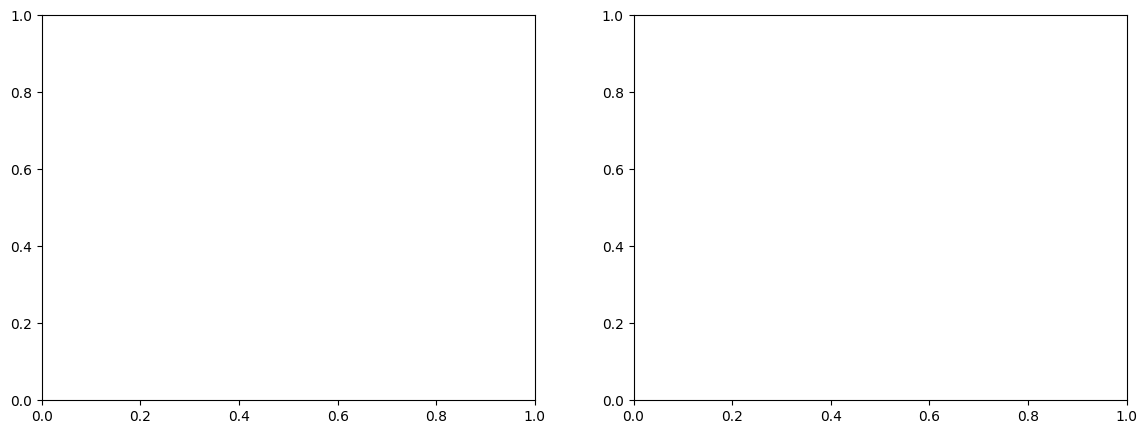

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
hpo.plot_pareto_front(study, ax=axes[0])
hpo.plot_param_importance(study, ax=axes[1])
plt.tight_layout()
plt.show()

### 3.3 Tabular Summary

`trials_to_dataframe` converts completed trials into a `pandas.DataFrame` with one row per trial and columns for every hyperparameter plus the two objective values (`objective_0`, `objective_1`). Pruned trials (killed by early stopping) are excluded by default.

In [5]:
df = hpo.trials_to_dataframe(study)
print(f"Completed trials: {len(df)}")
df.sort_values("mean_cal_error").head(10)

Completed trials: 10


,trial_number,cf_depth,cf_subnet_width,cf_subnet_depth,cf_dropout,cf_activation,ds_summary_dim,ds_depth,ds_width,ds_dropout,initial_lr,mean_cal_error,param_count,training_time_s,inference_time_s,nrmse,correlation
8,24,7,32,1,0.036409,silu,15,3,32,0.284823,0.000898,0.010,48668,42.66,0.20,0.096747,0.932755
2,9,4,32,1,0.048366,silu,29,4,64,0.267768,0.000825,0.022,214200,64.14,0.18,0.095424,0.902900
7,23,3,64,1,0.022695,silu,30,4,64,0.176988,0.000698,0.066,218675,47.55,0.17,0.097771,0.927856
0,1,11,64,1,0.055021,relu,12,3,64,0.087643,0.000419,0.078,179665,62.49,0.43,0.088550,0.909080
5,17,8,32,1,0.199051,mish,24,3,64,0.213654,0.000253,0.094,173579,52.73,0.28,0.104174,0.933256
6,20,3,64,1,0.019065,silu,27,4,32,0.276163,0.000951,0.094,64176,41.76,0.17,0.092405,0.936971
4,15,5,32,3,0.263202,mish,20,3,64,0.027931,0.003345,0.094,188053,56.98,0.35,0.085925,0.929549
3,12,5,32,2,0.150804,mish,10,1,128,0.295695,0.000258,0.122,280459,39.65,0.24,0.093474,0.951772
1,8,7,128,1,0.032367,relu,18,4,64,0.123115,0.001922,0.138,242175,63.90,0.43,0.110608,0.926123
9,25,9,32,1,0.024578,silu,12,3,32,0.261382,0.001094,0.146,49093,52.35,0.25,0.092413,0.943912


### 3.4 Best Trial

Print the hyperparameter configuration of the Pareto-optimal trial with the lowest calibration error — this is the architecture you would use for downstream inference.

In [6]:
pareto = hpo.get_pareto_trials(study)
best = min(pareto, key=lambda t: t.values[0])

print(f"Best Pareto trial #{best.number}")
print(f"  Calibration error : {best.values[0]:.4f}")
print(f"  Normalized size   : {best.values[1]:.4f}")
print("\nHyperparameters:")
for k, v in best.params.items():
    print(f"  {k}: {v}")

Best Pareto trial #24
  Calibration error : 0.0100
  Normalized size   : 0.7812

Hyperparameters:
  cf_depth: 7
  cf_subnet_width: 32
  cf_subnet_depth: 1
  cf_dropout: 0.03640856151849517
  cf_activation: silu
  ds_summary_dim: 15
  ds_depth: 3
  ds_width: 32
  ds_dropout: 0.28482273473892367
  initial_lr: 0.0008981030902828482
